# Model 0 & Model 1: Baseline models

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('..')

In [3]:
import pandas as pd
import numpy as np

from src.features import add_all_features
from src.evaluation import compute_metrics, append_to_experiment_table, plot_confusion_matrix
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from src.evaluation import train_and_evaluate

pd.set_option('display.max_colwidth', None)

### Load precomputed features

Loaded from a cached CSV (generated once in `01_eda.ipynb` via `add_all_features` + `raw_df.to_csv(...)`) instead of recomputing here -- feature generation now includes lemmatization/POS-tagging, which takes several minutes on the full dataset, so it's only run once, not in every notebook.

In [4]:
raw_df = pd.read_csv('/Users/nadiiababanska/Desktop/claude_coowork/ML_final_project/quora_with_features.csv', index_col=0)

### Train/validation split

In [5]:
# deviding of train daset on train and val
X = raw_df.drop(columns=['is_duplicate'])
y = raw_df['is_duplicate']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

#### Model 0.1: majority class baseline

In [6]:
majority_class = y_train.value_counts().idxmax()
y_pred_majority = np.full(len(y_val), majority_class)
y_prob_majority = np.full(len(y_val), y_train.mean())

In [7]:

results_model_0_1 = compute_metrics(y_val, y_pred_majority, y_prob_majority, 'Model 0.1: Majority class baseline', threshold=None)

model: Model 0.1: Majority class baseline

threshold: None

params: None

train_time_sec: None

train_f1: None

train_roc_auc: None

train_log_loss: None

f1: 0.0

roc_auc: 0.5

log_loss: 0.6585279444319896



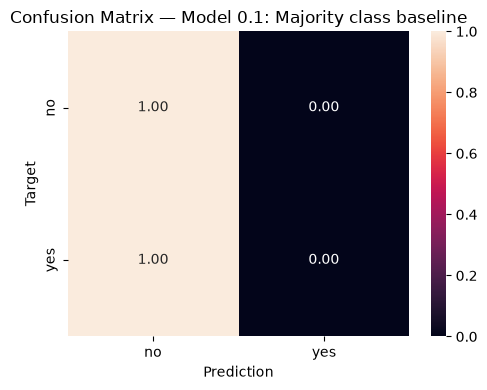

In [8]:
plot_confusion_matrix(y_val, y_pred_majority, 'Model 0.1: Majority class baseline')


In [9]:
append_to_experiment_table(results_model_0_1, path='/Users/nadiiababanska/Desktop/claude_coowork/ML_final_project/reports/experiment_table.csv')

#### Model 0.2: cosine similarity

In [10]:
#chosing of threshold

best_f1, best_threshold = 0, 0
for threshold in np.arange(0.1, 0.9, 0.05):
    y_pred_temp = (X_train['cosine_similarity'] > threshold).astype(int)
    f1 = f1_score(y_train, y_pred_temp)
    if f1 > best_f1:
        best_f1, best_threshold = f1, threshold

#prediction on val
y_pred = (X_val['cosine_similarity'] > best_threshold).astype(int)

In [11]:
#metrics calculation

results_model_0_2 = compute_metrics(y_val, y_pred, X_val['cosine_similarity'], 'Model 0.2: cosine similarity', threshold=best_threshold)


model: Model 0.2: cosine similarity

threshold: 0.3500000000000001

params: None

train_time_sec: None

train_f1: None

train_roc_auc: None

train_log_loss: None

f1: 0.63113377147741

roc_auc: 0.73442959225784

log_loss: 1.1061281457092904



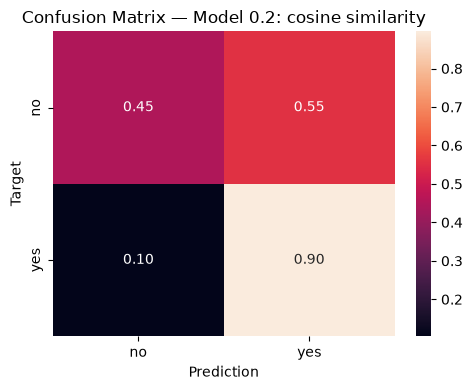

In [12]:
plot_confusion_matrix(y_val, y_pred, 'Model 0.2: cosine similarity')



In [13]:
append_to_experiment_table(results_model_0_2, path='/Users/nadiiababanska/Desktop/claude_coowork/ML_final_project/reports/experiment_table.csv')

#### Model 1 - Logistic regression

In [14]:
feature_cols = ['question1_len', 'question2_len', 'len_dif', 'common_words',
                 'jaccard_similarity', 'word_match_share', 'bigrams_common',
                 'bigram_jaccard_similarity', 'bigram_word_match_share', 'cosine_similarity']

X_train_log = X_train[feature_cols]
X_val_log = X_val[feature_cols]

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_log)
X_val_scaled = scaler.transform(X_val_log)

In [16]:
MAX_ITER = 1000
LR_model = LogisticRegression(max_iter=MAX_ITER, solver='sag', class_weight='balanced', C=0.1)

model: Model 1 - Logistic regression

threshold: None

params: {'C': 0.1, 'class_weight': 'balanced', 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': 0.0, 'max_iter': 1000, 'n_jobs': None, 'penalty': 'deprecated', 'random_state': None, 'solver': 'sag', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}

train_time_sec: 1.1951019763946533

train_f1: 0.6779808269700054

train_roc_auc: 0.7931786604767809

train_log_loss: 0.5243319554331859

f1: 0.6795781857893659

roc_auc: 0.7948072037984095

log_loss: 0.5226725275407242



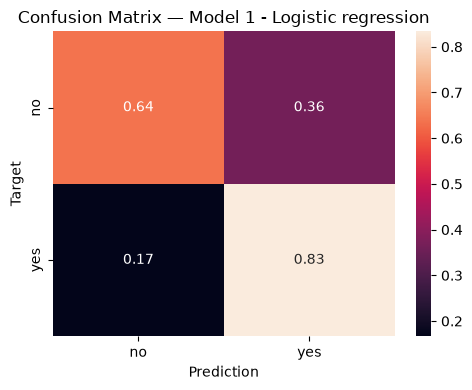

In [17]:
model_log_fitted, results_model_1 = train_and_evaluate(LR_model, X_train_scaled, y_train, X_val_scaled, y_val, 'Model 1 - Logistic regression', threshold=None)